# AmEx Contest Dataset — EDA & Cleaning (Collaborative Notebook)

This notebook is the shared, running record of exploratory data analysis and cleaning decisions on `dataset.csv` (500,000 rows, 23 features + `id`), per the EDA & Cleaning task list (Sections A–H below). It's meant to be handed off/reviewed as-is — each section has a **Goal** cell before the code and a **Findings** cell after it summarizing what the code showed.

**Files in this folder:**
- `dataset.csv` — raw data (never modified)
- `feature_desc.csv` — feature-name → description mapping
- `dataset_clean.csv` — output of Section H: imputed + flagged, 500,000 rows × 29 cols
- `findings_summary.md` — standalone one-page version of the findings below
- `correlation_matrix.png`, `dist_histograms_boxplots.png`, `low_cardinality_barcharts.png` — charts from Sections F/G

**Cells 1–3** below are a quick warm-up done before the formal task list started: pulling the first 1,000 rows and renaming columns via `feature_desc.csv` for a quick look. The full 500K-row EDA proper begins at **Section A**.

**Open decisions still needed from a human before scoring logic is written** (see Section H for full detail):
1. f2/f3 binary-flag inconsistency (54,205 rows have a Collection call with no Cancellation call)
2. f17 vs f18 Lend Line subset violation (36.5% of overlap rows)
3. 97 cross-feature duplicate rows (excluding id)
4. How to treat the ~2.6% "at-cap" censored rows present in every continuous column


In [1]:
import pandas as pd

df = pd.read_csv('/Users/mudit_ai_computer/Desktop/AmEx/dataset.csv', nrows=1000)
print(df.shape)
df.head()

(1000, 24)


,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23
0,0,0.000000,0,1,98615.44,5620.938246,NaN,NaN,NaN,NaN,...,0.0,0.0,49.280210,1960.0,1900.0,2,1,0.0,2.0,NaN
1,1,0.000000,0,0,21241.06,10196.878460,13865.4026,425.04840,27.9986,0.000,...,196.0,5.0,63.759364,34300.0,34650.0,3,2,163620.0,3.0,NaN
2,2,1224.690475,0,1,NaN,16.160000,NaN,NaN,NaN,NaN,...,0.0,0.0,19.646836,NaN,NaN,1,1,NaN,9.0,NaN
3,3,0.000000,1,0,NaN,1635.316863,3231.1968,-269.15308,0.0000,0.000,...,0.0,0.0,9.143074,12348.0,12474.0,2,1,NaN,5.0,NaN
4,4,3824.366700,0,0,7140.87,5007.271790,4064.2152,16079.35060,377.9055,556.974,...,0.0,11.0,63.759364,3672.0,3528.0,3,1,68640.0,0.0,NaN


In [2]:
feature_map = pd.read_csv('/Users/mudit_ai_computer/Desktop/AmEx/feature_desc.csv')
mapping = dict(zip(feature_map['Feature Name'], feature_map['Feature Description']))
print(mapping)

df = df.rename(columns=mapping)
df.head()

{'id': 'id', 'f1': 'Average Revolve Balance in last 12m', 'f2': 'Cancellation Calls in last 12m', 'f3': 'Cancellation Calls due to Collection', 'f4': 'Rewards Points Balance', 'f5': 'Total Spend in last 12m', 'f6': 'Airlines Spend in 12m', 'f7': 'Other Spend in 12m', 'f8': 'Entertainment Spend in 12m', 'f9': 'Lodging Spend in 12m', 'f10': 'Dining Spend in 12m', 'f11': 'Average Risk Score in 12m', 'f12': 'Login Counts to website', 'f13': 'Lounge Access Count', 'f14': 'Credits used in airlines', 'f15': 'Cab benefits usage', 'f16': 'Entertainment Credit Used Amount', 'f17': 'Total Lend Line Amount', 'f18': 'Total Consumer Lend Line Amount', 'f19': 'Number of Supplementary Accounts', 'f20': 'Count of Active Charge Cards', 'f21': 'Rewards point redeemed in 12months', 'f22': 'Emails Open in Last 6 months', 'f23': 'Emails Clicked in Last 6 months'}


,id,Average Revolve Balance in last 12m,Cancellation Calls in last 12m,Cancellation Calls due to Collection,Rewards Points Balance,Total Spend in last 12m,Airlines Spend in 12m,Other Spend in 12m,Entertainment Spend in 12m,Lodging Spend in 12m,...,Credits used in airlines,Cab benefits usage,Entertainment Credit Used Amount,Total Lend Line Amount,Total Consumer Lend Line Amount,Number of Supplementary Accounts,Count of Active Charge Cards,Rewards point redeemed in 12months,Emails Open in Last 6 months,Emails Clicked in Last 6 months
0,0,0.000000,0,1,98615.44,5620.938246,NaN,NaN,NaN,NaN,...,0.0,0.0,49.280210,1960.0,1900.0,2,1,0.0,2.0,NaN
1,1,0.000000,0,0,21241.06,10196.878460,13865.4026,425.04840,27.9986,0.000,...,196.0,5.0,63.759364,34300.0,34650.0,3,2,163620.0,3.0,NaN
2,2,1224.690475,0,1,NaN,16.160000,NaN,NaN,NaN,NaN,...,0.0,0.0,19.646836,NaN,NaN,1,1,NaN,9.0,NaN
3,3,0.000000,1,0,NaN,1635.316863,3231.1968,-269.15308,0.0000,0.000,...,0.0,0.0,9.143074,12348.0,12474.0,2,1,NaN,5.0,NaN
4,4,3824.366700,0,0,7140.87,5007.271790,4064.2152,16079.35060,377.9055,556.974,...,0.0,11.0,63.759364,3672.0,3528.0,3,1,68640.0,0.0,NaN


In [3]:
df.to_csv('/Users/mudit_ai_computer/Desktop/AmEx/small_dataset.csv', index=False)
print("Saved.")

Saved.


## Section A — Structural Checks
**Goal:** load the full 500K dataset, confirm row/column counts, check dtypes (catching numeric columns accidentally read as text due to blank cells), confirm no duplicate `id`s, and confirm no fully-duplicate rows.

In [4]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

df_full = pd.read_csv('/Users/mudit_ai_computer/Desktop/AmEx/dataset.csv')
print("Shape:", df_full.shape)
print("\nColumns:", list(df_full.columns))

Shape: (500000, 24)

Columns: ['id', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23']


In [5]:
print("=== DTYPES ===")
print(df_full.dtypes)

print("\n=== Object-typed columns (potential hidden numerics) ===")
obj_cols = df_full.select_dtypes(include='object').columns.tolist()
print(obj_cols)
for c in obj_cols:
    print(f"\n-- {c} --")
    print(df_full[c].unique()[:20])

=== DTYPES ===
id       int64
f1     float64
f2       int64
f3       int64
f4     float64
f5     float64
f6     float64
f7     float64
f8     float64
f9     float64
f10    float64
f11    float64
f12    float64
f13    float64
f14    float64
f15    float64
f16    float64
f17    float64
f18    float64
f19    float64
f20    float64
f21    float64
f22    float64
f23    float64
dtype: object

=== Object-typed columns (potential hidden numerics) ===
[]


In [6]:
print("=== Duplicate ID check ===")
dup_ids = df_full['id'].duplicated().sum()
print(f"Duplicate id count: {dup_ids}")
print(f"Unique ids: {df_full['id'].nunique()} / {len(df_full)}")
print(f"id min/max: {df_full['id'].min()} / {df_full['id'].max()}")

print("\n=== Fully duplicate rows ===")
dup_rows = df_full.duplicated().sum()
print(f"Fully duplicate rows: {dup_rows}")

print("\n=== Duplicate rows ignoring id ===")
dup_rows_no_id = df_full.drop(columns=['id']).duplicated().sum()
print(f"Duplicate rows (excluding id): {dup_rows_no_id}")

=== Duplicate ID check ===
Duplicate id count: 0
Unique ids: 500000 / 500000
id min/max: 0 / 499999

=== Fully duplicate rows ===


Fully duplicate rows: 0

=== Duplicate rows ignoring id ===
Duplicate rows (excluding id): 97


### A. Findings
- 500,000 rows × 24 cols (id + 23 features) confirmed.
- All columns numeric — no dtype issues, no hidden text/blank-corrupted columns.
- No duplicate `id`s (0–499999, all unique). No fully-duplicate rows.
- **97 rows are duplicate across all 23 features when `id` is excluded** — flagged for manual review (coincidence given continuous features vs. synthetic/padded records).

## Section B — Missingness Audit
**Goal:** compute % missing per column, test whether missingness is structural (co-occurs with other columns / product not applicable) vs. genuinely random, and produce a per-column imputation recommendation.

In [7]:
missing_pct = (df_full.isna().sum() / len(df_full) * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    'missing_count': df_full.isna().sum(),
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)
print(missing_summary)

     missing_count  missing_pct
f23         438965      87.7930
f18         309444      61.8888
f17         292254      58.4508
f21         257228      51.4456
f4          257228      51.4456
f7          115698      23.1396
f9          115698      23.1396
f10         115698      23.1396
f8          115698      23.1396
f6          115698      23.1396
f22          94654      18.9308
f12          25005       5.0010
f14          13716       2.7432
f15          13716       2.7432
f16          13716       2.7432
f13          13716       2.7432
f5            6340       1.2680
f11           2510       0.5020
f20            101       0.0202
f19             22       0.0044
f1               0       0.0000
f3               0       0.0000
f2               0       0.0000
id               0       0.0000


In [8]:
feature_map = pd.read_csv('/Users/mudit_ai_computer/Desktop/AmEx/feature_desc.csv')
name_map = dict(zip(feature_map['Feature Name'], feature_map['Feature Description']))

missing_summary_named = missing_summary.copy()
missing_summary_named['description'] = missing_summary_named.index.map(name_map)
print(missing_summary_named)

     missing_count  missing_pct                           description
f23         438965      87.7930       Emails Clicked in Last 6 months
f18         309444      61.8888       Total Consumer Lend Line Amount
f17         292254      58.4508                Total Lend Line Amount
f21         257228      51.4456    Rewards point redeemed in 12months
f4          257228      51.4456                Rewards Points Balance
f7          115698      23.1396                    Other Spend in 12m
f9          115698      23.1396                  Lodging Spend in 12m
f10         115698      23.1396                   Dining Spend in 12m
f8          115698      23.1396            Entertainment Spend in 12m
f6          115698      23.1396                 Airlines Spend in 12m
f22          94654      18.9308          Emails Open in Last 6 months
f12          25005       5.0010               Login Counts to website
f14          13716       2.7432              Credits used in airlines
f15          13716  

In [9]:
# Check if missingness co-occurs exactly for groups with identical counts
groups_to_check = {
    'spend_subcats (f6,f7,f8,f9,f10)': ['f6','f7','f8','f9','f10'],
    'rewards (f4,f21)': ['f4','f21'],
    'lend_line (f17,f18)': ['f17','f18'],
    'usage_credits (f13,f14,f15,f16)': ['f13','f14','f15','f16'],
}

for name, cols in groups_to_check.items():
    mask = df_full[cols].isna()
    print(f"\n--- {name} ---")
    # how many rows match the "all missing together" pattern vs partial
    all_na = mask.all(axis=1).sum()
    any_na = mask.any(axis=1).sum()
    print(f"All-NaN together: {all_na}, Any-NaN: {any_na}, individual counts: {mask.sum().to_dict()}")
    # pairwise agreement
    print("Row-wise NaN pattern value counts (top 5):")
    print(mask.apply(lambda r: tuple(r), axis=1).value_counts().head(5))


--- spend_subcats (f6,f7,f8,f9,f10) ---
All-NaN together: 115698, Any-NaN: 115698, individual counts: {'f6': 115698, 'f7': 115698, 'f8': 115698, 'f9': 115698, 'f10': 115698}
Row-wise NaN pattern value counts (top 5):


(False, False, False, False, False)    384302
(True, True, True, True, True)         115698
Name: count, dtype: int64

--- rewards (f4,f21) ---
All-NaN together: 257228, Any-NaN: 257228, individual counts: {'f4': 257228, 'f21': 257228}
Row-wise NaN pattern value counts (top 5):


(True, True)      257228
(False, False)    242772
Name: count, dtype: int64

--- lend_line (f17,f18) ---
All-NaN together: 292254, Any-NaN: 309444, individual counts: {'f17': 292254, 'f18': 309444}
Row-wise NaN pattern value counts (top 5):


(True, True)      292254
(False, False)    190556
(False, True)      17190
Name: count, dtype: int64

--- usage_credits (f13,f14,f15,f16) ---
All-NaN together: 13716, Any-NaN: 13716, individual counts: {'f13': 13716, 'f14': 13716, 'f15': 13716, 'f16': 13716}
Row-wise NaN pattern value counts (top 5):


(False, False, False, False)    486284
(True, True, True, True)         13716
Name: count, dtype: int64


In [10]:
# Check email cols relationship f22 (opened) vs f23 (clicked) - clicks require opens
mask_email = df_full[['f22','f23']].isna()
print("Email missingness pattern (f22=Opens, f23=Clicks):")
print(mask_email.apply(lambda r: tuple(r), axis=1).value_counts())

# Does f23 missing only when f22 missing, or independently?
print("\nWhen f22 present, f23 missing count:", df_full[df_full['f22'].notna()]['f23'].isna().sum(), "/", df_full['f22'].notna().sum())
print("When f22 missing, f23 missing count:", df_full[df_full['f22'].isna()]['f23'].isna().sum(), "/", df_full['f22'].isna().sum())

Email missingness pattern (f22=Opens, f23=Clicks):


(False, True)     344311
(True, True)       94654
(False, False)     61035
Name: count, dtype: int64

When f22 present, f23 missing count: 344311 / 405346
When f22 missing, f23 missing count: 94654 / 94654


In [11]:
# When opens present, check relationship between opens value and clicks missingness
sub = df_full[df_full['f22'].notna()]
print("Opens=0 rows -> clicks missing?:")
print(sub[sub['f22']==0]['f23'].isna().value_counts())
print("\nOpens>0 rows -> clicks missing?:")
print(sub[sub['f22']>0]['f23'].isna().value_counts())
print("\nOpens>0 & clicks present -> describe clicks:")
print(sub[(sub['f22']>0) & (sub['f23'].notna())]['f23'].describe())

Opens=0 rows -> clicks missing?:
f23
True    51966
Name: count, dtype: int64

Opens>0 rows -> clicks missing?:
f23
True     292345
False     61035
Name: count, dtype: int64

Opens>0 & clicks present -> describe clicks:
count    61035.000000
mean         1.309904
std          0.599658
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: f23, dtype: float64


In [12]:
# Cross-tab: Rewards Points Balance (f4) missing vs Total Spend (f5) and Active Charge Cards (f20)
print("=== Total Spend (f5) by Rewards Balance (f4) missingness ===")
print(df_full.groupby(df_full['f4'].isna())['f5'].describe())

print("\n=== Active Charge Cards (f20) by Rewards Balance (f4) missingness ===")
print(df_full.groupby(df_full['f4'].isna())['f20'].describe())

print("\n=== Total Spend (f5) by Spend-subcat (f6-f10) missingness ===")
print(df_full.groupby(df_full['f6'].isna())['f5'].describe())

print("\n=== Active Charge Cards (f20) by Lend Line (f17) missingness ===")
print(df_full.groupby(df_full['f17'].isna())['f20'].describe())

=== Total Spend (f5) by Rewards Balance (f4) missingness ===
          count         mean          std  min         25%          50%          75%         max
f4                                                                                              
False  241316.0  3971.003682  4076.513777  0.0  737.639150  2549.422293  5885.564710  13596.2799
True   252344.0  2980.744598  3250.681003  0.0  621.357191  1890.310779  4123.161738  13596.2799

=== Active Charge Cards (f20) by Rewards Balance (f4) missingness ===
          count      mean       std  min  25%  50%  75%  max
f4                                                          
False  242772.0  1.196501  0.397353  1.0  1.0  1.0  1.0  2.0
True   257127.0  1.189249  0.391707  1.0  1.0  1.0  1.0  2.0

=== Total Spend (f5) by Spend-subcat (f6-f10) missingness ===
          count         mean          std  min         25%          50%          75%         max
f6                                                                          

In [13]:
# Check f13-f16 (benefit usage) missingness vs f20 (active cards) - premium benefit hypothesis
print("=== Active Charge Cards by Benefit-usage (f13) missingness ===")
print(df_full.groupby(df_full['f13'].isna())['f20'].describe())

print("\n=== f17 (Lend Line) presence vs f13 (benefit) missingness cross-tab ===")
print(pd.crosstab(df_full['f13'].isna(), df_full['f17'].isna()))

# f5 total spend / f11 risk score / f12 login / f19 / f20 - check if these are just small random missing
print("\n=== f12 Login Counts missing vs Total Spend ===")
print(df_full.groupby(df_full['f12'].isna())['f5'].describe())

=== Active Charge Cards by Benefit-usage (f13) missingness ===
          count      mean      std  min  25%  50%  75%  max
f13                                                        
False  486190.0  1.191612  0.39357  1.0  1.0  1.0  1.0  2.0
True    13709.0  1.233861  0.42330  1.0  1.0  1.0  1.0  2.0

=== f17 (Lend Line) presence vs f13 (benefit) missingness cross-tab ===
f17     False   True 
f13                  
False  201401  284883
True     6345    7371

=== f12 Login Counts missing vs Total Spend ===
          count         mean          std  min         25%          50%          75%         max
f12                                                                                             
False  469415.0  3451.271709  3690.813428  0.0  672.256126  2165.710117  4891.225253  13596.2799
True    24245.0  3726.996504  4069.279430  0.0  605.981461  2170.078946  5407.373535  13596.2799


In [14]:
recommendations = {
    'f4':  ('Rewards Points Balance', 51.45, 'Impute 0 + add has_rewards_program flag', 'Co-missing 100% with f21; likely product w/o rewards program, not a data gap'),
    'f21': ('Rewards point redeemed in 12m', 51.45, 'Impute 0 (uses has_rewards_program flag from f4)', 'Perfectly co-missing with f4 (257,228 rows both or neither)'),
    'f17': ('Total Lend Line Amount', 58.45, 'Impute 0 + add has_lend_line flag', 'Charge-card-only customers (pay-in-full) logically have no revolving lend line'),
    'f18': ('Total Consumer Lend Line Amount', 61.89, 'Impute 0 (uses has_lend_line flag)', 'Missing whenever f17 missing, +17,190 extra rows -> subset/stricter product flag'),
    'f6':  ('Airlines Spend in 12m', 23.14, 'Impute 0 + add spend_breakdown_available flag', 'f6-f10 co-missing exactly together (115,698 rows); Total Spend (f5) still present -> breakdown untracked, not zero total'),
    'f7':  ('Other Spend in 12m', 23.14, 'Impute 0 (same flag as f6)', 'See f6'),
    'f8':  ('Entertainment Spend in 12m', 23.14, 'Impute 0 (same flag as f6)', 'See f6'),
    'f9':  ('Lodging Spend in 12m', 23.14, 'Impute 0 (same flag as f6)', 'See f6'),
    'f10': ('Dining Spend in 12m', 23.14, 'Impute 0 (same flag as f6)', 'See f6'),
    'f22': ('Emails Open in Last 6m', 18.93, 'Impute 0 + add has_email_on_file flag', 'Likely no email/opt-out on file for this segment'),
    'f23': ('Emails Clicked in Last 6m', 87.79, 'Impute 0 (NOT a flag col)', 'Confirmed structural zero: always missing when Opens=0; when Opens>0 & present, values are always >=1 (never 0) -> NaN=0 clicks'),
    'f12': ('Login Counts to website', 5.00, 'Impute median (or 0 - check skew)', 'No structural link found to other cols; looks like genuine small random gap'),
    'f13': ('Lounge Access Count', 2.74, 'Impute 0', 'Co-missing exactly with f14,f15,f16 (13,716 rows); no link to card tier (f20) found -> treat as random small gap, 0 is safe default for a count'),
    'f14': ('Credits used in airlines', 2.74, 'Impute 0', 'Co-missing with f13/f15/f16'),
    'f15': ('Cab benefits usage', 2.74, 'Impute 0', 'Co-missing with f13/f14/f16'),
    'f16': ('Entertainment Credit Used Amount', 2.74, 'Impute 0', 'Co-missing with f13/f14/f15'),
    'f5':  ('Total Spend in last 12m', 1.27, 'Impute median', 'Small random gap, no structural pattern'),
    'f11': ('Average Risk Score in 12m', 0.50, 'Impute median (needs manual review of range first - see Section C)', 'Small random gap'),
    'f20': ('Count of Active Charge Cards', 0.02, 'Impute mode (likely 1)', 'Negligible, random'),
    'f19': ('Number of Supplementary Accounts', 0.004, 'Impute mode/0', 'Negligible, random'),
}

rec_df = pd.DataFrame.from_dict(recommendations, orient='index',
                                  columns=['description','missing_pct','recommendation','rationale'])
print(rec_df.to_string())

                          description  missing_pct                                                      recommendation                                                                                                                                        rationale
f4             Rewards Points Balance       51.450                             Impute 0 + add has_rewards_program flag                                                                     Co-missing 100% with f21; likely product w/o rewards program, not a data gap
f21     Rewards point redeemed in 12m       51.450                    Impute 0 (uses has_rewards_program flag from f4)                                                                                      Perfectly co-missing with f4 (257,228 rows both or neither)
f17            Total Lend Line Amount       58.450                                   Impute 0 + add has_lend_line flag                                                                   Charge-card-only custom

### B. Findings
Five column groups are **missing in perfect lockstep** (same rows every time) — the strongest evidence their NaNs are structural ("not applicable"), not random data gaps:

| Group | Columns | % missing | Decision |
|---|---|---|---|
| Rewards | f4 (Balance), f21 (Redeemed) | 51.4% | Impute 0 + `has_rewards_program` flag |
| Lend line | f17 (Total), f18 (Consumer) | 58.4% / 61.9% | Impute 0 + `has_lend_line`/`has_consumer_lend_line` flags (f18 has 17,190 extra NaNs beyond f17) |
| Spend subcategories | f6, f7, f8, f9, f10 | 23.1% | Impute 0 + `spend_breakdown_available` flag |
| Benefit usage | f13, f14, f15, f16 | 2.7% | Impute 0, no flag (no link found to a product-tier column, treated as genuine small gap) |
| Email | f22 (Opens), f23 (Clicks) | 18.9% / 87.8% | f22: impute 0 + `has_email_on_file` flag. f23: impute 0, **no flag needed** — confirmed structural zero (always NaN when Opens=0; when present, values are always ≥1, never 0) |

Remaining columns (f5, f11, f12, f19, f20; ≤5% missing each) showed no structural link to any other column — imputed with median (f5, f11, f12) or mode (f19, f20) as ordinary random gaps. See the recommendation table printed above for the full per-column rationale.

## Section C — Range & Sanity Checks
**Goal:** min/max/mean/median/std for every numeric column, flag illogical negatives, confirm binary/range assumptions (e.g. Risk Score bounds), and check whether Collection Calls is logically ≤ Total Cancellation Calls.

In [15]:
numeric_cols = [c for c in df_full.columns if c != 'id']
desc = df_full[numeric_cols].describe().T
desc['description'] = desc.index.map(name_map)
desc['n_negative'] = (df_full[numeric_cols] < 0).sum()
print(desc[['description','min','max','mean','50%','std','n_negative']].to_string())

                              description          min            max           mean           50%            std  n_negative
f1    Average Revolve Balance in last 12m     0.000000   17967.726330    2467.312088      0.000000    4801.261745           0
f2         Cancellation Calls in last 12m     0.000000       1.000000       0.173948      0.000000       0.379065           0
f3   Cancellation Calls due to Collection     0.000000       1.000000       0.108608      0.000000       0.311147           0
f4                 Rewards Points Balance     2.000000  697899.350000  126607.131109  50705.190000  183366.588497           0
f5                Total Spend in last 12m     0.000000   13596.279900    3464.813312   2165.850798    3710.776424           0
f6                  Airlines Spend in 12m     0.000000   52198.432000   10032.050115   4022.766000   13981.489112           0
f7                     Other Spend in 12m  -274.646000  146700.554000   30821.546800  14396.270950   39491.042972     

In [16]:
# f2/f3 look binary (0/1) not counts - verify
print("f2 (Cancellation Calls) unique:", sorted(df_full['f2'].unique()))
print("f3 (Cancellation Calls due to Collection) unique:", sorted(df_full['f3'].unique()))

# Logical consistency: Collection calls (f3) should be <= Total cancellation calls (f2)
violation = (df_full['f3'] > df_full['f2']).sum()
print(f"\nRows where Collection calls (f3) > Total Cancellation calls (f2): {violation}")
print(pd.crosstab(df_full['f2'], df_full['f3'], rownames=['f2 (total)'], colnames=['f3 (collection)']))

# f7 Other Spend negatives - check magnitude, is it refunds (small negatives) or errors (huge negatives)?
print("\nf7 negative value stats:")
print(df_full[df_full['f7']<0]['f7'].describe())

# f16 min check - never 0?
print(f"\nf16 min: {df_full['f16'].min()}, rows with f16==0: {(df_full['f16']==0).sum()}")

f2 (Cancellation Calls) unique: [np.int64(0), np.int64(1)]
f3 (Cancellation Calls due to Collection) unique: [np.int64(0), np.int64(1)]

Rows where Collection calls (f3) > Total Cancellation calls (f2): 54205
f3 (collection)       0      1
f2 (total)                    
0                358821  54205
1                 86875     99

f7 negative value stats:
count    2.245100e+04
mean    -2.492907e+02
std      6.173856e+01
min     -2.746460e+02
25%     -2.746460e+02
50%     -2.718995e+02
75%     -2.664066e+02
max     -2.750000e-14
Name: f7, dtype: float64

f16 min: 8.876771196, rows with f16==0: 0


### C. Findings
- **f2/f3 are binary flags (0/1), not counts.** 54,205 rows (10.8%) have a Collection call (f3=1) with **no** Cancellation call (f2=0) — breaks the expected "collection calls are a subset of cancellation calls" assumption. **Needs a definitional decision before use.**
- f7 (Other Spend) has 22,451 negative values, tightly bounded (-274.65 to ~0) — consistent with refunds, not errors. No other spend column has negatives.
- f11 (Risk Score) ranges 0–0.326 → treat as a 0–1 probability-type score, not 0–100.
- f16 (Entertainment Credit Used) never reaches 0 (floor of 8.88) — likely a minimum allocated credit, not an anomaly.

## Section D — Outlier Detection
**Goal:** for each continuous variable, compare 90th/95th/99th/99.9th percentiles vs. max, flag rows >10x the 99th percentile as possible data errors, and compute skew to flag log-transform candidates.

In [18]:
continuous_cols = ['f1','f4','f5','f6','f7','f8','f9','f10','f11','f12','f16','f17','f18','f21']
rows = []
for c in continuous_cols:
    s = df_full[c].dropna()
    p90,p95,p99,p999 = s.quantile([.90,.95,.99,.999]).tolist()
    mx = s.max()
    rows.append({
        'col': c, 'name': name_map[c],
        'p90': p90, 'p95': p95, 'p99': p99, 'p99.9': p999, 'max': mx,
        'max/p99_ratio': mx/p99 if p99>0 else np.nan,
        'skew': s.skew()
    })
outlier_df = pd.DataFrame(rows).set_index('col')
print(outlier_df.to_string())

                                    name            p90            p95            p99          p99.9            max  max/p99_ratio      skew
col                                                                                                                                         
f1   Average Revolve Balance in last 12m    9496.962158   17249.017280   17967.726330   17967.726330   17967.726330            1.0  2.229196
f4                Rewards Points Balance  395594.868000  669983.376000  697899.350000  697899.350000  697899.350000            1.0  1.971216
f5               Total Spend in last 12m    9336.884852   13052.428700   13596.279900   13596.279900   13596.279900            1.0  1.371610
f6                 Airlines Spend in 12m   31367.622630   50110.494720   52198.432000   52198.432000   52198.432000            1.0  1.825405
f7                    Other Spend in 12m   91944.576960  140832.531800  146700.554000  146700.554000  146700.554000            1.0  1.692012
f8           

In [19]:
# p99/p99.9/max being identical suggests a hard cap. Verify: how many rows sit AT the max value?
for c in ['f1','f4','f5','f6','f11','f17']:
    mx = df_full[c].max()
    n_at_max = (df_full[c] == mx).sum()
    n_within_1pct = (df_full[c] >= mx*0.999).sum()
    print(f"{c}: max={mx:.4f}, rows exactly at max={n_at_max}, rows within 0.1% of max={n_within_1pct}")

f1: max=17967.7263, rows exactly at max=12933, rows within 0.1% of max=12952
f4: max=697899.3500, rows exactly at max=6245, rows within 0.1% of max=6256
f5: max=13596.2799, rows exactly at max=12915, rows within 0.1% of max=12942
f6: max=52198.4320, rows exactly at max=9916, rows within 0.1% of max=9925
f11: max=0.3263, rows exactly at max=12837, rows within 0.1% of max=12849
f17: max=63800.0000, rows exactly at max=5538, rows within 0.1% of max=5560


In [20]:
# Check ALL continuous cols for capping, and confirm none exceed 10x p99 (impossible if capped)
cap_rows = []
for c in continuous_cols:
    s = df_full[c].dropna()
    mx = s.max()
    p99 = s.quantile(.99)
    pct_at_cap = (s == mx).sum() / len(s) * 100
    extreme_flag = (s > p99*10).sum()
    cap_rows.append({'col': c, 'name': name_map[c], 'pct_rows_at_max_value': round(pct_at_cap,2),
                      'skew': round(s.skew(),2), 'rows_over_10x_p99': extreme_flag})
cap_df = pd.DataFrame(cap_rows).set_index('col')
print(cap_df.to_string())

                                    name  pct_rows_at_max_value  skew  rows_over_10x_p99
col                                                                                     
f1   Average Revolve Balance in last 12m                   2.59  2.23                  0
f4                Rewards Points Balance                   2.57  1.97                  0
f5               Total Spend in last 12m                   2.62  1.37                  0
f6                 Airlines Spend in 12m                   2.58  1.83                  0
f7                    Other Spend in 12m                   2.60  1.69                  0
f8            Entertainment Spend in 12m                   2.58  2.03                  0
f9                  Lodging Spend in 12m                   2.58  2.13                  0
f10                  Dining Spend in 12m                   2.60  1.61                  0
f11            Average Risk Score in 12m                   2.58  2.76                  0
f12              Logi

### D. Findings — the data is capped, not organically tailed
Every continuous column has **~2.6% of rows sitting exactly at its max value** (f16 is capped on 35% of rows). Consequently p99 = p99.9 = max in every column, and **zero rows exceed 10x the 99th percentile** anywhere — the ceiling already absorbs what would otherwise be extreme values. This looks like the dataset was winsorized/clipped at generation time, not naturally fat-tailed.

**Implication:** treat the at-cap rows as *censored*, not naturally large — consider a `*_at_cap` indicator per column if these features drive scoring, since a plain log/standardize step will understate how extreme the true tail may actually be.

Skew: f1, f4, f6, f8, f9, f11, f21 are strongly right-skewed (1.4–2.8) → log-transform candidates. f16 is left-skewed (-1.44, driven by the cap + floor). f17/f18 are only mildly skewed (0.5–0.6) → fine as-is.

## Section E — Internal Consistency Checks
**Goal:** test whether related columns behave the way their names imply — do spend subcategories sum to Total Spend, is one Lend Line column a subset of the other, do Rewards Balance and Redeemed move independently, and are Active Charge Cards / Supplementary Accounts consistent?

In [21]:
# E1: Do Airlines+Other+Entertainment+Lodging+Dining sum to Total Spend?
subcats = ['f6','f7','f8','f9','f10']
have_all = df_full[subcats].notna().all(axis=1) & df_full['f5'].notna()
sub_sum = df_full.loc[have_all, subcats].sum(axis=1)
total = df_full.loc[have_all, 'f5']
diff = (sub_sum - total).abs()
tol = 1.0  # rounding tolerance
match = (diff <= tol).sum()
print(f"Rows with all subcats + total present: {have_all.sum()}")
print(f"Rows where subcats sum ~= Total Spend (tol=1.0): {match} ({match/have_all.sum()*100:.2f}%)")
print(f"Diff stats:\n{diff.describe()}")

Rows with all subcats + total present: 380164
Rows where subcats sum ~= Total Spend (tol=1.0): 33 (0.01%)
Diff stats:
count    380164.000000
mean      45770.609744
std       55045.368597
min           0.000000
25%        6473.234183
50%       23663.688346
75%       63276.079418
max      240798.436000
dtype: float64


In [22]:
# Subcats sum vastly exceeds Total Spend -- these are NOT components of it. Check correlation/ratio instead.
print("Correlation(sub_sum, Total Spend):", np.corrcoef(sub_sum, total)[0,1])
print("\nMean by column vs Total Spend mean (3464.81):")
for c in subcats:
    print(f"  {c} ({name_map[c]}): mean={df_full[c].mean():.2f}")
print(f"  f5 Total Spend: mean={df_full['f5'].mean():.2f}")
print("\n-> Conclusion: f6-f10 are NOT sub-components of f5; likely separate spend/limit metrics on a different scale/definition.")

Correlation(sub_sum, Total Spend): 0.09892526492744445

Mean by column vs Total Spend mean (3464.81):
  f6 (Airlines Spend in 12m): mean=10032.05
  f7 (Other Spend in 12m): mean=30821.55
  f8 (Entertainment Spend in 12m): mean=1522.99
  f9 (Lodging Spend in 12m): mean=1651.74
  f10 (Dining Spend in 12m): mean=4536.38
  f5 Total Spend: mean=3464.81

-> Conclusion: f6-f10 are NOT sub-components of f5; likely separate spend/limit metrics on a different scale/definition.


In [23]:
# E2: Lend Line (f17) vs Consumer Lend Line (f18)
both = df_full[['f17','f18']].dropna()
print("Corr(f17,f18):", both['f17'].corr(both['f18']))
print("f18 <= f17 violation count:", (both['f18'] > both['f17']).sum(), "/", len(both))
print(both.describe())

# E3: Rewards Points Balance (f4) vs Redeemed (f21)
both2 = df_full[['f4','f21']].dropna()
print("\nCorr(f4,f21):", both2['f4'].corr(both2['f21']))
print("f21 > f4 count (redeemed more than balance?):", (both2['f21'] > both2['f4']).sum(), "/", len(both2))

# E4: Active Charge Cards (f20) vs Supplementary Accounts (f19)
print("\nf19 > f20 (more supplementary accounts than active cards):", (df_full['f19'] > df_full['f20']).sum(), "/", len(df_full))
print(pd.crosstab(df_full['f20'], df_full['f19']))

Corr(f17,f18): 0.9001336453776738
f18 <= f17 violation count: 69577 / 190556
                 f17            f18
count  190556.000000  190556.000000
mean    24465.750798   21976.069885
std     17409.822353   15343.872912
min      1000.000000    1000.000000
25%      9984.000000    9310.000000
50%     22145.000000   19998.000000
75%     34845.000000   33026.000000
max     63800.000000   54800.000000

Corr(f4,f21): 0.15224937527257693
f21 > f4 count (redeemed more than balance?): 91105 / 242772

f19 > f20 (more supplementary accounts than active cards): 211178 / 500000
f19     1.0     2.0    3.0    4.0
f20                              
1.0  247301  108002  33031  15199
2.0     284   41136  25175  29771


### E. Findings — overturns an assumption
- **f6–f10 (spend subcategories) do NOT sum to f5 (Total Spend)** — correlation is only 0.099, and subcategory sums average ~13x larger than Total Spend. These are **independent features on their own scale**, not a breakdown of Total Spend.
- **f17 vs f18 (Lend Line pair): corr = 0.90 (near-duplicate)**, but 36.5% of overlapping rows have f18 > f17, violating the assumed subset relationship — needs a definitional check.
- **f4 vs f21 (Rewards Balance vs Redeemed): corr = 0.15** — confirmed independent signals, not redundant. 37.5% of rows show redeemed > balance, plausibly a different rolling-window definition.
- **f19 (Supplementary Accounts) > f20 (Active Charge Cards) in 42% of rows** — not necessarily an error (multiple supplementary cardholders can sit under one active account), flagged for confirmation.

## Section F — Distribution Visualization
**Goal:** histograms/boxplots for key continuous variables and bar charts for low-cardinality columns, saved as PNGs for review (not decisions yet).

In [24]:
import sys
print(sys.executable)
print(sys.version)

/Users/mudit_ai_computer/Desktop/AmEx/.venv/bin/python
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]


Matplotlib is building the font cache; this may take a moment.


/var/folders/f_/40yzt90j3892w_gwxcvv2dc40000gn/T/ipykernel_20782/3357216383.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(s, vert=False)
/var/folders/f_/40yzt90j3892w_gwxcvv2dc40000gn/T/ipykernel_20782/3357216383.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(s, vert=False)
/var/folders/f_/40yzt90j3892w_gwxcvv2dc40000gn/T/ipykernel_20782/3357216383.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(s, vert=False)
/var/folders/f_/40yzt90j3892w_gwxcvv2dc40000gn/T/ipykernel_20782/3357216383.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be remov

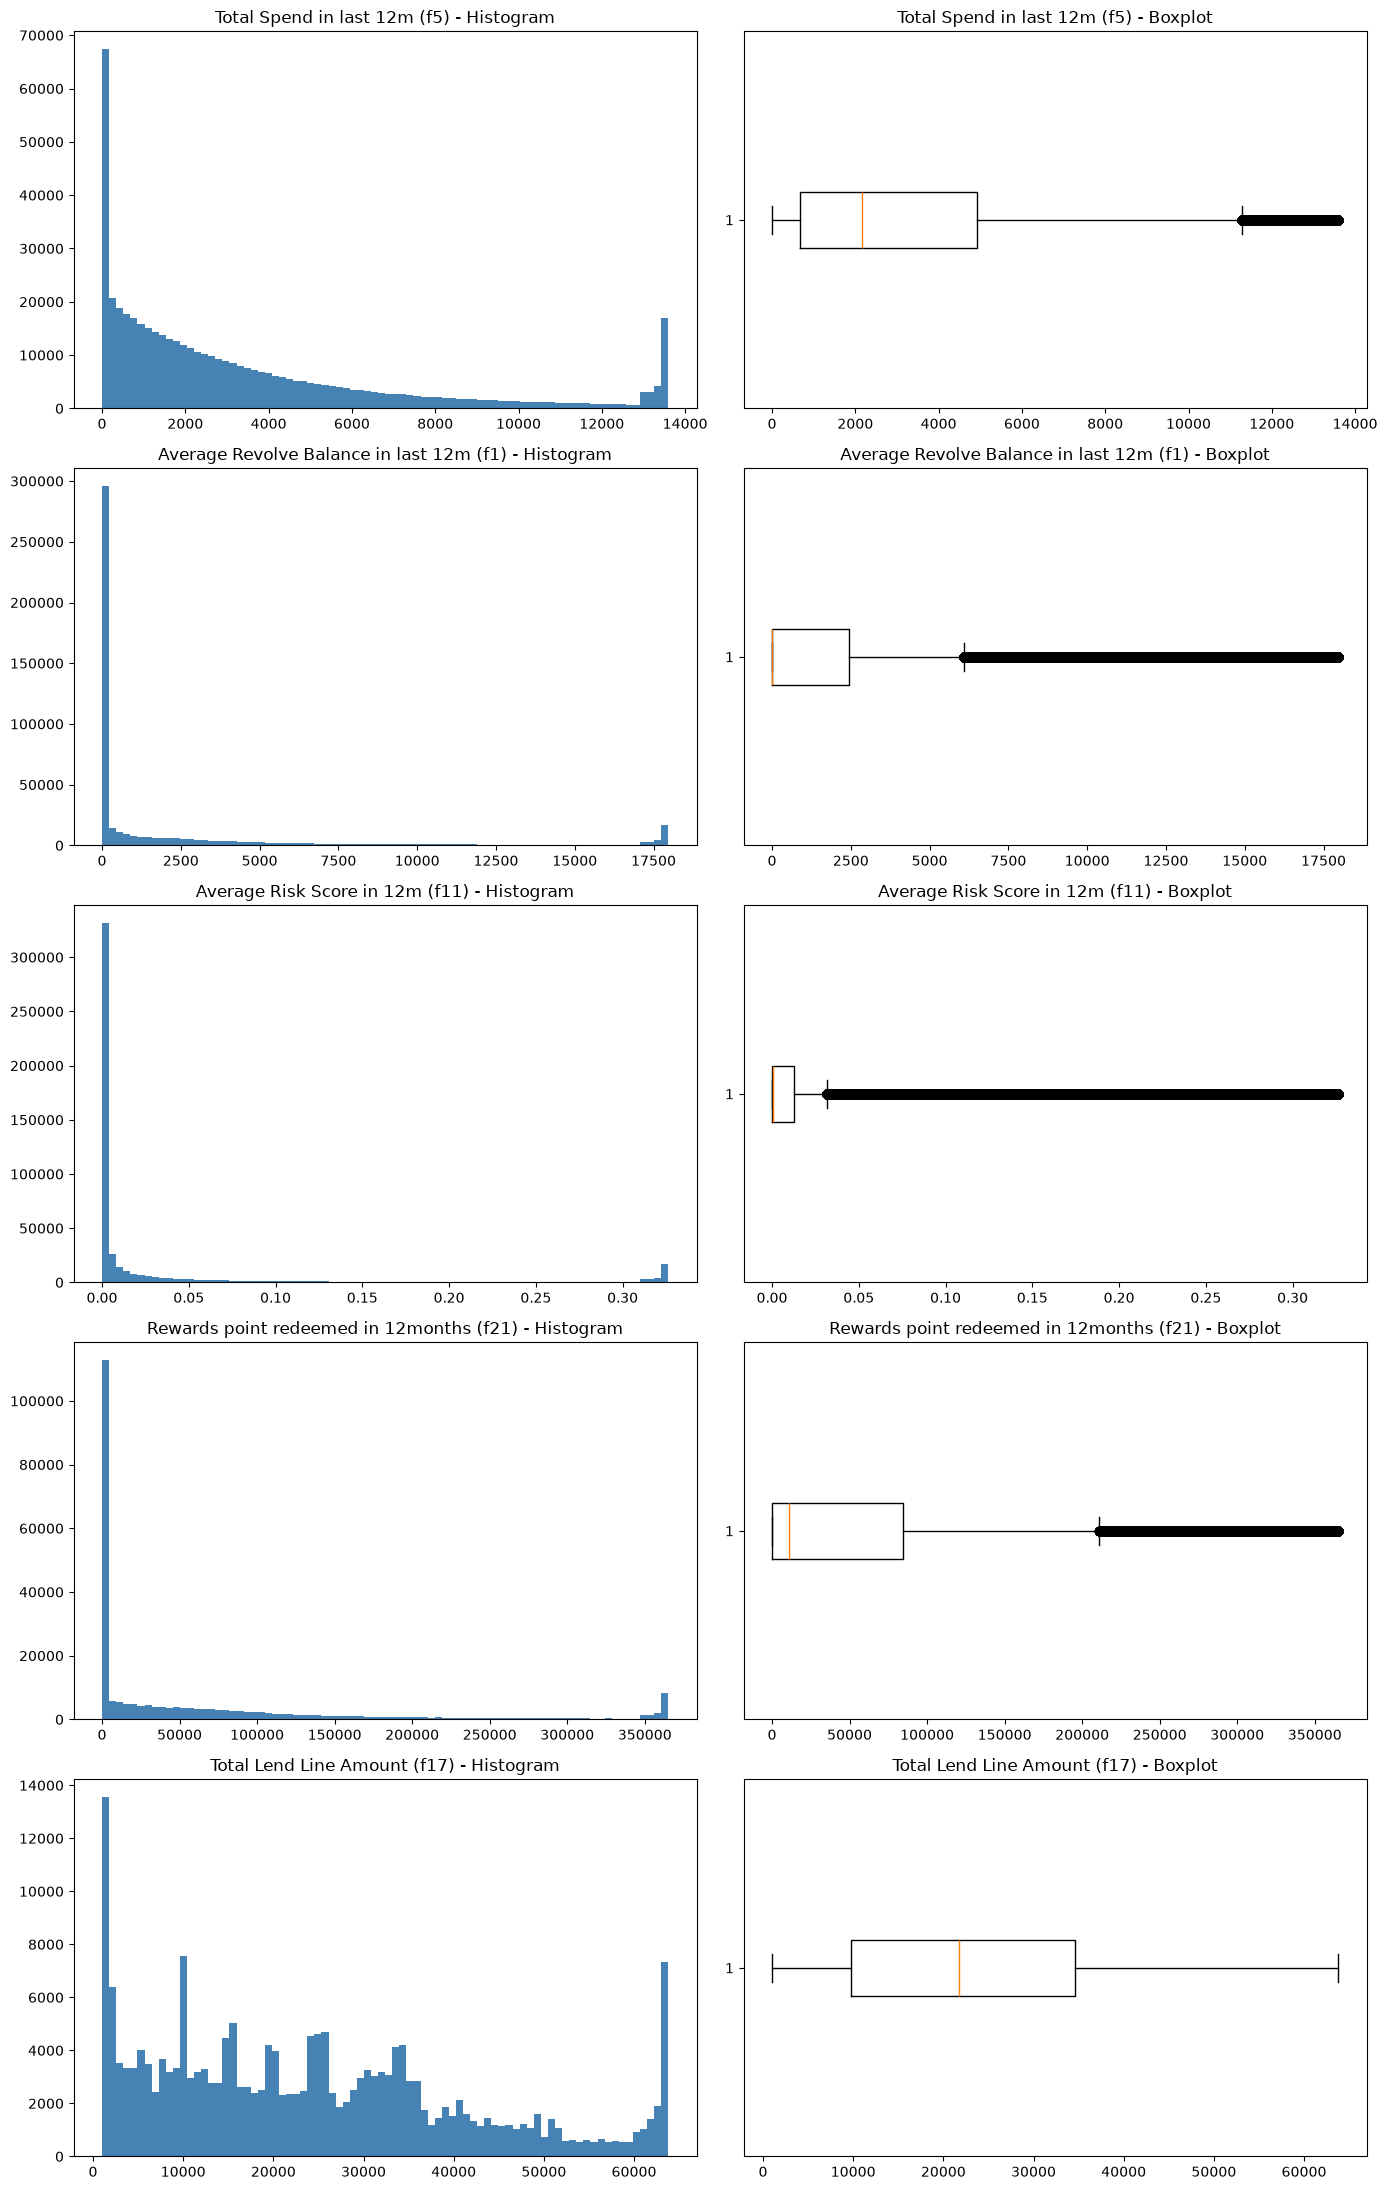

Saved to dist_histograms_boxplots.png


In [25]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
key_vars = ['f5','f1','f11','f21','f17']
titles = [name_map[c] for c in key_vars]

for i, c in enumerate(key_vars):
    s = df_full[c].dropna()
    axes[i,0].hist(s, bins=80, color='steelblue', edgecolor='none')
    axes[i,0].set_title(f'{titles[i]} ({c}) - Histogram')
    axes[i,1].boxplot(s, vert=False)
    axes[i,1].set_title(f'{titles[i]} ({c}) - Boxplot')

plt.tight_layout()
plt.savefig('/Users/mudit_ai_computer/Desktop/AmEx/dist_histograms_boxplots.png', dpi=100)
plt.show()
print("Saved to dist_histograms_boxplots.png")

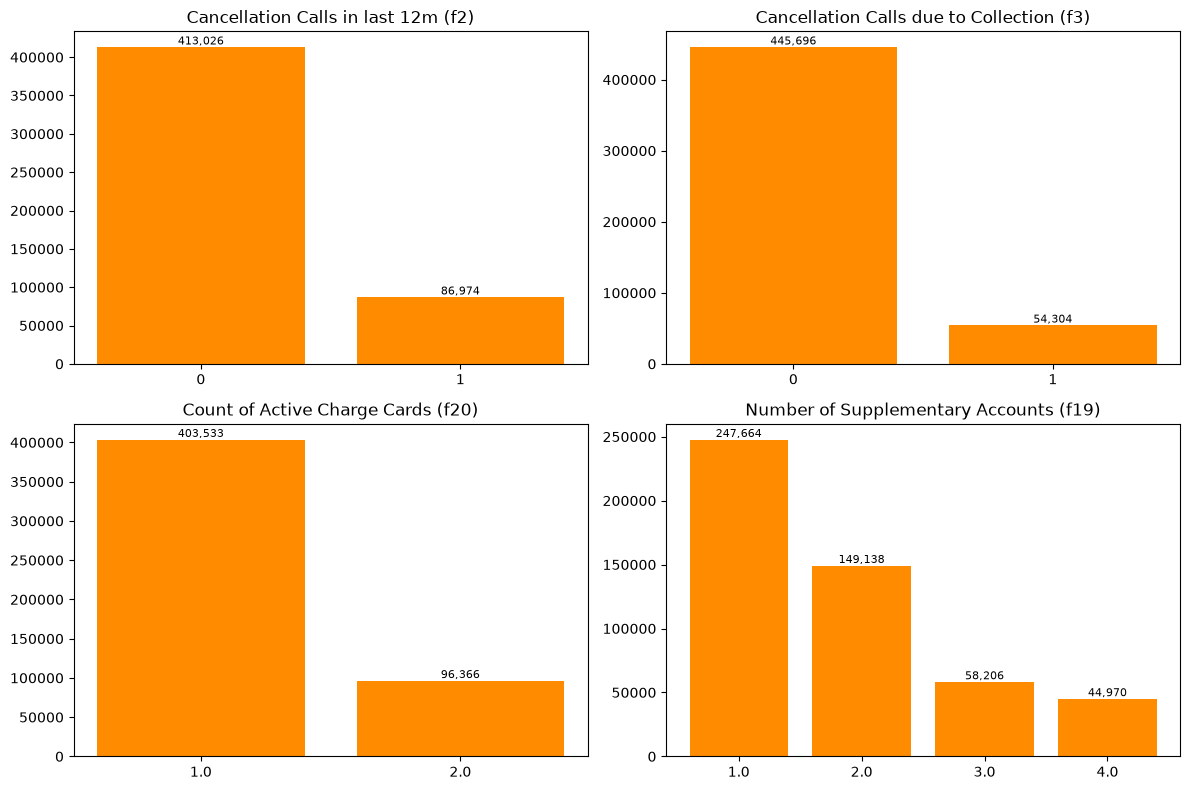

Saved to low_cardinality_barcharts.png


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
low_card_vars = ['f2','f3','f20','f19']
for ax, c in zip(axes.flat, low_card_vars):
    vc = df_full[c].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='darkorange')
    ax.set_title(f'{name_map[c]} ({c})')
    for i, v in enumerate(vc.values):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/Users/mudit_ai_computer/Desktop/AmEx/low_cardinality_barcharts.png', dpi=100)
plt.show()
print("Saved to low_cardinality_barcharts.png")

### F. Findings
Charts saved to `dist_histograms_boxplots.png` and `low_cardinality_barcharts.png`. The histograms visibly show the capping spike at the right edge for f5, f1, f11, f21 (matches Section D). f17 (Total Lend Line) has an unusually wavy/multimodal shape rather than a smooth decay — worth a second look if it feeds into scoring.

## Section G — Correlation Matrix
**Goal:** full pairwise correlation across the 23 features; flag redundant pairs (|corr| > 0.6) that risk double-weighting the same signal.

In [27]:
feature_cols = [c for c in df_full.columns if c != 'id']
corr = df_full[feature_cols].corr()

# rename to descriptive labels for the printed pairs
pairs = []
for i, c1 in enumerate(feature_cols):
    for c2 in feature_cols[i+1:]:
        r = corr.loc[c1, c2]
        if abs(r) > 0.6:
            pairs.append({'col1': c1, 'name1': name_map[c1], 'col2': c2, 'name2': name_map[c2], 'corr': r})

pairs_df = pd.DataFrame(pairs).sort_values('corr', key=abs, ascending=False)
print(f"Pairs with |corr| > 0.6: {len(pairs_df)}\n")
print(pairs_df.to_string(index=False))

Pairs with |corr| > 0.6: 4

col1                      name1 col2                           name2     corr
 f17     Total Lend Line Amount  f18 Total Consumer Lend Line Amount 0.900134
  f6      Airlines Spend in 12m   f9            Lodging Spend in 12m 0.703491
  f7         Other Spend in 12m  f10             Dining Spend in 12m 0.664629
  f8 Entertainment Spend in 12m  f10             Dining Spend in 12m 0.619932


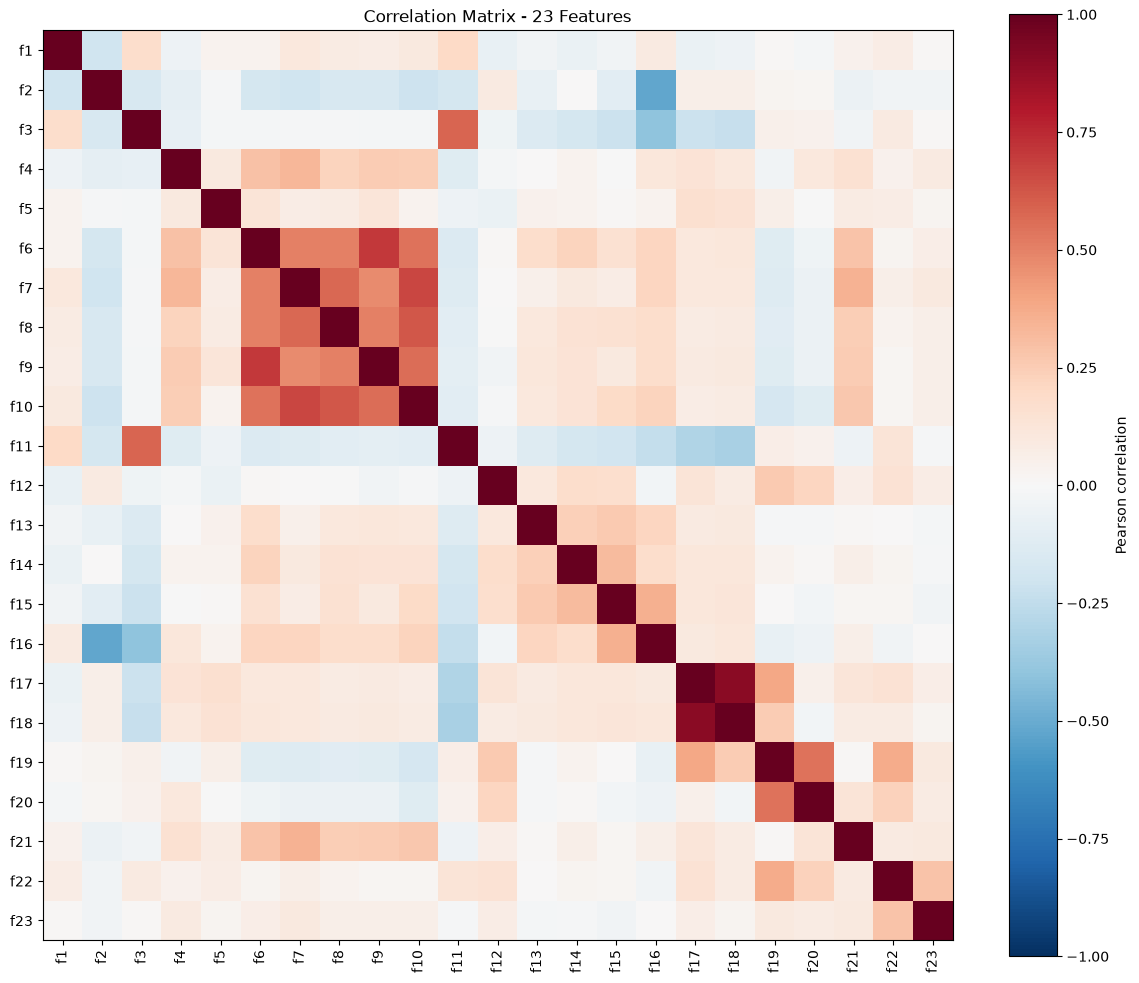

Saved to correlation_matrix.png

Full matrix (rounded):
       f1    f2    f3    f4    f5    f6    f7    f8    f9   f10   f11   f12   f13   f14   f15   f16   f17   f18   f19   f20   f21   f22   f23
f1   1.00 -0.20  0.17 -0.05  0.03  0.04  0.11  0.08  0.07  0.09  0.20 -0.07 -0.03 -0.06 -0.03  0.09 -0.06 -0.05  0.01 -0.02  0.05  0.07  0.01
f2  -0.20  1.00 -0.16 -0.09 -0.02 -0.18 -0.20 -0.16 -0.16 -0.21 -0.18  0.09 -0.08  0.00 -0.11 -0.52  0.06  0.06  0.03  0.02 -0.06 -0.03 -0.03
f3   0.17 -0.16  1.00 -0.08 -0.02 -0.02 -0.01 -0.01 -0.02 -0.02  0.58 -0.04 -0.14 -0.17 -0.22 -0.40 -0.21 -0.23  0.05  0.04 -0.03  0.09  0.01
f4  -0.05 -0.09 -0.08  1.00  0.09  0.29  0.33  0.22  0.25  0.25 -0.12 -0.02  0.01  0.04 -0.00  0.12  0.14  0.10 -0.03  0.10  0.15  0.04  0.09
f5   0.03 -0.02 -0.02  0.09  1.00  0.13  0.08  0.08  0.12  0.04 -0.05 -0.06  0.05  0.03  0.01  0.03  0.16  0.14  0.06 -0.01  0.08  0.07  0.03
f6   0.04 -0.18 -0.02  0.29  0.13  1.00  0.50  0.51  0.70  0.54 -0.13  0.01  0.18  0.22  0.1

In [28]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols))); ax.set_xticklabels(feature_cols, rotation=90)
ax.set_yticks(range(len(feature_cols))); ax.set_yticklabels(feature_cols)
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation Matrix - 23 Features')
plt.tight_layout()
plt.savefig('/Users/mudit_ai_computer/Desktop/AmEx/correlation_matrix.png', dpi=100)
plt.show()
print("Saved to correlation_matrix.png")
print("\nFull matrix (rounded):")
print(corr.round(2).to_string())

### G. Findings
Only 4 pairs exceed |corr| > 0.6:

| Pair | Corr |
|---|---|
| f17 (Total Lend Line) / f18 (Consumer Lend Line) | 0.90 |
| f6 (Airlines Spend) / f9 (Lodging Spend) | 0.70 |
| f7 (Other Spend) / f10 (Dining Spend) | 0.66 |
| f8 (Entertainment Spend) / f10 (Dining Spend) | 0.62 |

f17/f18 is the clearest double-counting risk for scoring — consider using only one, or a combined feature. The f6–f10 cluster is moderately intercorrelated (0.5–0.7 among themselves) despite not summing to Total Spend (see Section E), so weighting all five independently may overweight a shared "spend propensity" signal. (f3/f11 at 0.58 and f2/f16 at -0.52 sit just under threshold but are worth a glance in the heatmap above.)

## Section H — Output: Clean Dataset & Findings Summary
**Goal:** apply the Section B/C/D/E decisions to produce a fully-imputed, flagged dataset saved separately from the raw file, and write a one-page findings summary for review before scoring logic is written.

In [29]:
df_clean = df_full.copy()

# --- Structural-zero groups: add availability flags BEFORE imputing ---
df_clean['has_rewards_program'] = df_full['f4'].notna().astype(int)      # f4, f21
df_clean['has_lend_line'] = df_full['f17'].notna().astype(int)           # f17
df_clean['has_consumer_lend_line'] = df_full['f18'].notna().astype(int)  # f18 (subset flag, extra 17,190 NaNs beyond f17)
df_clean['spend_breakdown_available'] = df_full['f6'].notna().astype(int)  # f6-f10
df_clean['has_email_on_file'] = df_full['f22'].notna().astype(int)       # f22

zero_impute_cols = ['f4','f21','f17','f18','f6','f7','f8','f9','f10','f22','f23','f13','f14','f15','f16']
for c in zero_impute_cols:
    df_clean[c] = df_clean[c].fillna(0)

# --- Small random-gap columns: median/mode impute ---
for c in ['f5','f11','f12']:
    df_clean[c] = df_clean[c].fillna(df_full[c].median())

df_clean['f20'] = df_clean['f20'].fillna(df_full['f20'].mode()[0])
df_clean['f19'] = df_clean['f19'].fillna(df_full['f19'].mode()[0])

print("Remaining NaNs after cleaning:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
print("\nShape:", df_clean.shape)
print("Columns added:", [c for c in df_clean.columns if c not in df_full.columns])

Remaining NaNs after cleaning:
Series([], dtype: int64)

Shape: (500000, 29)
Columns added: ['has_rewards_program', 'has_lend_line', 'has_consumer_lend_line', 'spend_breakdown_available', 'has_email_on_file']


In [30]:
df_clean.to_csv('/Users/mudit_ai_computer/Desktop/AmEx/dataset_clean.csv', index=False)
print("Saved dataset_clean.csv:", df_clean.shape)

Saved dataset_clean.csv: (500000, 29)


### H. Findings
`dataset_clean.csv` saved: 500,000 rows × 29 cols (23 original + `id` + 5 new availability flags: `has_rewards_program`, `has_lend_line`, `has_consumer_lend_line`, `spend_breakdown_available`, `has_email_on_file`). Zero missing values remain. Raw `dataset.csv` is untouched — nothing overwritten.

---

## 📋 Full Findings Summary (for review before any scoring logic is written)

**Dataset:** 500,000 rows × 23 features + id. All numeric, no dtype issues. No duplicate ids, no fully-duplicate rows. **97 rows duplicate across all 23 features excluding `id`** — flag for manual review.

**Outputs in this folder:** `dataset_clean.csv`, `findings_summary.md`, `correlation_matrix.png`, `dist_histograms_boxplots.png`, `low_cardinality_barcharts.png`.

### 1. Missingness — decisions taken
Five column groups are missing in perfect lockstep (structural "not applicable," not random gaps):

| Group | Columns | % missing | Decision |
|---|---|---|---|
| Rewards | f4, f21 | 51.4% | Impute 0 + `has_rewards_program` flag |
| Lend line | f17, f18 | 58.4% / 61.9% | Impute 0 + `has_lend_line`/`has_consumer_lend_line` flags |
| Spend subcategories | f6–f10 | 23.1% | Impute 0 + `spend_breakdown_available` flag |
| Benefit usage | f13–f16 | 2.7% | Impute 0, no flag |
| Email | f22, f23 | 18.9% / 87.8% | f22: impute 0 + `has_email_on_file` flag. f23: impute 0, no flag (confirmed structural zero) |

Remaining columns (f5, f11, f12, f19, f20) imputed with median/mode as ordinary random gaps.

### 2. Range & sanity issues
- **f2/f3 are binary flags, not counts.** 54,205 rows (10.8%) have a Collection call with no Cancellation call — breaks the expected subset relationship. **Needs a decision.**
- f7 (Other Spend) has 22,451 negatives, tightly bounded — consistent with refunds.
- f11 (Risk Score) is 0–1 scale, not 0–100.
- f16 (Entertainment Credit Used) floors at 8.88, never 0.

### 3. Outliers — the data is capped, not organically tailed
Every continuous column has ~2.6% of rows exactly at its max (f16: 35%). p99 = p99.9 = max everywhere → **zero rows exceed 10x p99**. The dataset appears winsorized/clipped at generation time; consider a censoring flag for at-cap rows rather than treating them as ordinary large values.

### 4. Internal consistency — overturns an assumption
- **f6–f10 do NOT sum to f5** (corr = 0.099) — independent features, not a Total Spend breakdown.
- **f17 vs f18: corr = 0.90** (near-duplicate) but 36.5% of overlap rows violate the assumed subset relationship.
- **f4 vs f21: corr = 0.15** — confirmed independent signals.
- **f19 > f20 in 42% of rows** — plausible (multiple supplementary cardholders per account) but flagged for confirmation.

### 5. Redundant columns (|corr| > 0.6)
f17/f18 (0.90), f6/f9 (0.70), f7/f10 (0.66), f8/f10 (0.62) — candidates for dropping one or combining before scoring.

### 6. Open items needing a human decision
1. f2/f3 binary-flag inconsistency (54,205 rows).
2. f17 vs f18 subset violation (36.5% of overlap rows).
3. 97 cross-feature duplicate rows (excluding id).
4. How to treat the ~2.6% at-cap "censored" rows in scoring.


## Section I — Deeper Correlation & Behavioral-Hypothesis Pass (2026-07-07 follow-up)
**Goal:** (1) redo the correlation heatmap with feature names instead of `f1`..`f23`; (2) resolve whether the f6–f10-vs-f5 gap is a scale mismatch or an outlier artifact via row-level ratios; (3) run Spearman alongside Pearson to catch monotonic relationships the linear matrix understates, and confirm the f11 (Risk Score) findings; (4) extend the f16 loss-aversion finding to the other three benefit variables and to f3 (involuntary calls); (5) test three new behavioral hypotheses grounded in psychology principles: silent churn (disengagement as an independent risk signal), the Family Approval Anchor (supplementary accounts → retention), and spend-concentration as a proxy for one-off "milestone" spend events. All results are logged in `assumptions_log.md` (Sections 2–4, 7–9).

In [31]:
print(df_full.shape, df_clean.shape)
print(list(name_map.items())[:3])

(500000, 24) (500000, 29)
[('id', 'id'), ('f1', 'Average Revolve Balance in last 12m'), ('f2', 'Cancellation Calls in last 12m')]


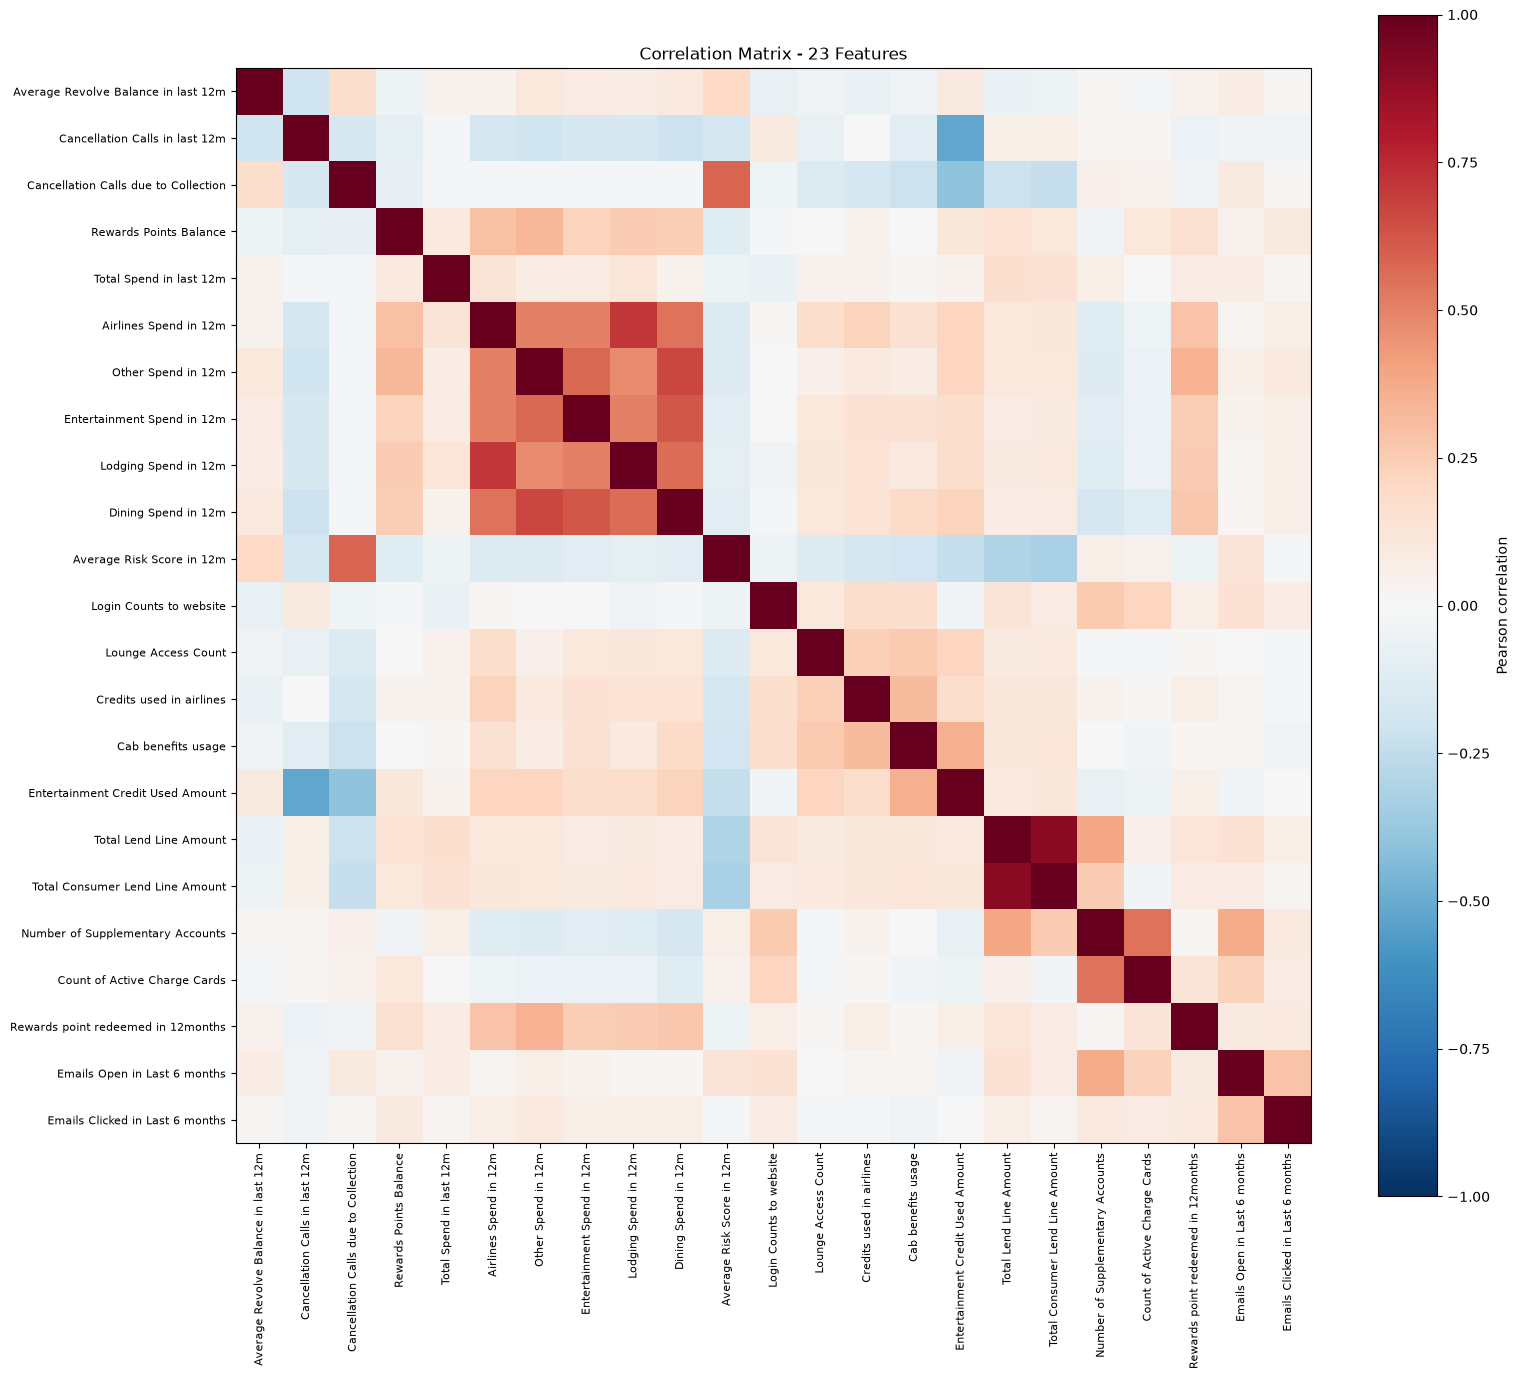

Overwrote correlation_matrix.png with named axes


In [32]:
# Regenerate correlation heatmap with descriptive feature names on both axes
labels = [name_map[c] for c in feature_cols]

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols))); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(feature_cols))); ax.set_yticklabels(labels, fontsize=8)
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation Matrix - 23 Features')
plt.tight_layout()
plt.savefig('/Users/mudit_ai_computer/Desktop/AmEx/correlation_matrix.png', dpi=100)
plt.show()
print("Overwrote correlation_matrix.png with named axes")

In [33]:
# Action 1: row-level f6_f10_sum vs f5 check
have_all = df_full[subcats].notna().all(axis=1) & df_full['f5'].notna()
sub = df_full.loc[have_all, ['f5'] + subcats].copy()
sub['f6_f10_sum'] = sub[subcats].sum(axis=1)
sub['diff'] = sub['f6_f10_sum'] - sub['f5']
sub['ratio'] = sub['f6_f10_sum'] / sub['f5'].replace(0, np.nan)

print("Rows analyzed:", len(sub))
print("\n=== diff (f6_f10_sum - f5) distribution ===")
print(sub['diff'].describe())
print("\n=== ratio (f6_f10_sum / f5) distribution ===")
print(sub['ratio'].describe())
print("\nRatio percentiles:")
print(sub['ratio'].quantile([.01,.05,.10,.25,.5,.75,.90,.95,.99]))
print("\nRows where f5==0 (ratio undefined):", (sub['f5']==0).sum())
print("Coefficient of variation of ratio (std/mean, excluding inf/na):", 
      sub['ratio'].replace([np.inf,-np.inf], np.nan).dropna().std() / sub['ratio'].replace([np.inf,-np.inf], np.nan).dropna().mean())

Rows analyzed: 380164

=== diff (f6_f10_sum - f5) distribution ===
count    380164.000000
mean      44977.296097
std       55695.460726
min      -13870.925900
25%        5465.113691
50%       23663.688346
75%       63276.079418
max      240798.436000
Name: diff, dtype: float64

=== ratio (f6_f10_sum / f5) distribution ===
count    3.536260e+05
mean     9.887113e+02
std      5.062649e+04
min     -3.256296e+02
25%      2.894964e+00
50%      1.057084e+01
75%      3.807612e+01
max      1.440435e+07
Name: ratio, dtype: float64

Ratio percentiles:
0.01       0.035819
0.05       0.284195
0.10       0.736310
0.25       2.894964
0.50      10.570842
0.75      38.076123
0.90     161.603389
0.95     496.755485
0.99    6768.648883
Name: ratio, dtype: float64

Rows where f5==0 (ratio undefined): 26538
Coefficient of variation of ratio (std/mean, excluding inf/na): 51.204524470972224


In [34]:
# Is the gap concentrated in a subset, or pervasive? Check what fraction of rows are "roughly 1:1" vs wildly off
ratio_clean = sub['ratio'].replace([np.inf,-np.inf], np.nan).dropna()
print(f"% of rows with ratio in [0.8, 1.25] (roughly matches, allowing rounding): {((ratio_clean>=0.8)&(ratio_clean<=1.25)).mean()*100:.2f}%")
print(f"% of rows with ratio > 2 (subcats at least 2x total): {(ratio_clean>2).mean()*100:.2f}%")
print(f"% of rows with ratio > 10 (subcats at least 10x total): {(ratio_clean>10).mean()*100:.2f}%")
print(f"% of rows with ratio < 1 (subcats LESS than total): {(ratio_clean<1).mean()*100:.2f}%")
print(f"\nMedian ratio is {ratio_clean.median():.2f}x -- gap is pervasive across the whole distribution, not just tail-driven.")
print(f"Ratio range spans {ratio_clean.max()/max(ratio_clean.min(),1e-9):.0f}x between min and max -- no fixed conversion factor exists per customer.")

% of rows with ratio in [0.8, 1.25] (roughly matches, allowing rounding): 3.84%
% of rows with ratio > 2 (subcats at least 2x total): 80.21%
% of rows with ratio > 10 (subcats at least 10x total): 51.17%
% of rows with ratio < 1 (subcats LESS than total): 12.42%

Median ratio is 10.57x -- gap is pervasive across the whole distribution, not just tail-driven.
Ratio range spans 14404353465227716x between min and max -- no fixed conversion factor exists per customer.


In [35]:
# Action 2a: f1 (Revolve Balance) conditioned on f11 (Risk Score) quartiles
risk_valid = df_full[['f1','f11']].dropna().copy()
risk_valid['risk_quartile'] = pd.qcut(risk_valid['f11'], 4, labels=['Q1 (lowest risk)','Q2','Q3','Q4 (highest risk)'], duplicates='drop')
print("=== f1 (Avg Revolve Balance) by f11 (Risk Score) quartile ===")
print(risk_valid.groupby('risk_quartile', observed=True)['f1'].agg(['mean','median','count']))

ValueError: Bin labels must be one fewer than the number of bin edges

In [36]:
print(risk_valid['f11'].quantile([0,.25,.5,.75,1]))
print("\n% of rows with f11==0:", (risk_valid['f11']==0).mean()*100)

0.00    0.000000
0.25    0.000000
0.50    0.000643
0.75    0.012678
1.00    0.326310
Name: f11, dtype: float64

% of rows with f11==0: 33.17031498120565


In [37]:
# f11 has 33% exact zeros, collapsing quartile edges. Split "zero risk" as its own group, then quartile the rest.
risk_valid['risk_bin'] = np.where(risk_valid['f11']==0, 'Zero risk (f11=0)',
                            pd.qcut(risk_valid.loc[risk_valid['f11']>0,'f11'], 3,
                                    labels=['Low-nonzero','Mid','High']).reindex(risk_valid.index).astype(str))

print("=== f1 (Avg Revolve Balance) by f11 (Risk Score) bin ===")
order = ['Zero risk (f11=0)','Low-nonzero','Mid','High']
result = risk_valid.groupby('risk_bin', observed=True)['f1'].agg(['mean','median','count']).reindex(order)
print(result)

=== f1 (Avg Revolve Balance) by f11 (Risk Score) bin ===
                          mean       median   count
risk_bin                                           
Zero risk (f11=0)   428.933049     0.000000  165019
Low-nonzero        1345.654589     0.000000  110872
Mid                3937.449970   491.750796  110776
High               5177.673374  2938.053542  110823


In [38]:
# Spearman correlation matrix (catches monotonic-but-nonlinear relationships Pearson understates)
spearman_corr = df_full[feature_cols].corr(method='spearman')

# Compare: where does Spearman diverge meaningfully from Pearson (|diff| > 0.15)?
diff_matrix = (spearman_corr - corr).abs()
diverge_pairs = []
for i, c1 in enumerate(feature_cols):
    for c2 in feature_cols[i+1:]:
        d = diff_matrix.loc[c1, c2]
        if d > 0.15:
            diverge_pairs.append({'col1': c1, 'name1': name_map[c1], 'col2': c2, 'name2': name_map[c2],
                                   'pearson': corr.loc[c1,c2], 'spearman': spearman_corr.loc[c1,c2], 'abs_diff': d})

diverge_df = pd.DataFrame(diverge_pairs).sort_values('abs_diff', ascending=False)
print(f"Pairs where |Spearman - Pearson| > 0.15: {len(diverge_df)}\n")
print(diverge_df.to_string(index=False))

Pairs where |Spearman - Pearson| > 0.15: 2

col1                               name1 col2                              name2  pearson  spearman  abs_diff
  f1 Average Revolve Balance in last 12m  f11          Average Risk Score in 12m 0.196084  0.576983  0.380900
  f4              Rewards Points Balance  f21 Rewards point redeemed in 12months 0.152249 -0.035776  0.188026


In [39]:
# Any pairs with |Spearman| > 0.6 that weren't already flagged under Pearson?
spearman_pairs = []
for i, c1 in enumerate(feature_cols):
    for c2 in feature_cols[i+1:]:
        r = spearman_corr.loc[c1, c2]
        if abs(r) > 0.6:
            spearman_pairs.append({'col1': c1, 'name1': name_map[c1], 'col2': c2, 'name2': name_map[c2], 'spearman': r, 'pearson': corr.loc[c1,c2]})

sp_df = pd.DataFrame(spearman_pairs).sort_values('spearman', key=abs, ascending=False)
print(f"Pairs with |Spearman| > 0.6: {len(sp_df)}\n")
print(sp_df.to_string(index=False))

Pairs with |Spearman| > 0.6: 6

col1                      name1 col2                           name2  spearman  pearson
 f17     Total Lend Line Amount  f18 Total Consumer Lend Line Amount  0.922697 0.900134
  f6      Airlines Spend in 12m   f9            Lodging Spend in 12m  0.712937 0.703491
  f7         Other Spend in 12m  f10             Dining Spend in 12m  0.703404 0.664629
  f8 Entertainment Spend in 12m  f10             Dining Spend in 12m  0.699648 0.619932
  f7         Other Spend in 12m   f8      Entertainment Spend in 12m  0.612379 0.573589
  f9       Lodging Spend in 12m  f10             Dining Spend in 12m  0.608625 0.560164


In [40]:
# Action 3: verify f11 vs f3, f17, f18 (confirming the "behaves per its name" finding, no new action)
print("f11 (Risk Score) vs f3 (Collection Calls):", corr.loc['f11','f3'], "| Spearman:", spearman_corr.loc['f11','f3'])
print("f11 (Risk Score) vs f17 (Total Lend Line):", corr.loc['f11','f17'], "| Spearman:", spearman_corr.loc['f11','f17'])
print("f11 (Risk Score) vs f18 (Consumer Lend Line):", corr.loc['f11','f18'], "| Spearman:", spearman_corr.loc['f11','f18'])

f11 (Risk Score) vs f3 (Collection Calls): 0.5826447612554053 | Spearman: 0.4541487088725753
f11 (Risk Score) vs f17 (Total Lend Line): -0.3003796737117531 | Spearman: -0.3546191254629252
f11 (Risk Score) vs f18 (Consumer Lend Line): -0.322456415764059 | Spearman: -0.3803797552804275


In [41]:
# Action 4: extend f16 finding -- f2 (voluntary cancellation) vs f13/f14/f15 individually, then f3 (collection/involuntary) vs all four
benefit_cols = ['f13','f14','f15','f16']
print("=== f2 (Cancellation Calls) vs benefit usage vars ===")
for b in benefit_cols:
    print(f"  f2 vs {b} ({name_map[b]}): Pearson={corr.loc['f2',b]:.4f}, Spearman={spearman_corr.loc['f2',b]:.4f}")

print("\n=== f3 (Collection Calls) vs benefit usage vars ===")
for b in benefit_cols:
    print(f"  f3 vs {b} ({name_map[b]}): Pearson={corr.loc['f3',b]:.4f}, Spearman={spearman_corr.loc['f3',b]:.4f}")

=== f2 (Cancellation Calls) vs benefit usage vars ===
  f2 vs f13 (Lounge Access Count): Pearson=-0.0771, Spearman=-0.0730
  f2 vs f14 (Credits used in airlines): Pearson=0.0022, Spearman=-0.0046
  f2 vs f15 (Cab benefits usage): Pearson=-0.1064, Spearman=-0.0800
  f2 vs f16 (Entertainment Credit Used Amount): Pearson=-0.5194, Spearman=-0.4615

=== f3 (Collection Calls) vs benefit usage vars ===
  f3 vs f13 (Lounge Access Count): Pearson=-0.1390, Spearman=-0.1513
  f3 vs f14 (Credits used in airlines): Pearson=-0.1720, Spearman=-0.1912
  f3 vs f15 (Cab benefits usage): Pearson=-0.2155, Spearman=-0.2241
  f3 vs f16 (Entertainment Credit Used Amount): Pearson=-0.3996, Spearman=-0.3785


In [42]:
# New: silent churn hypothesis. Among f2=0 (no cancellation call), segment by engagement proxies.
no_call = df_clean[df_clean['f2']==0].copy()  # use df_clean (imputed) so f12/f22/benefit cols have no NaNs
print("Customers with f2=0 (no cancellation call):", len(no_call))

# Engagement proxy = z-scored sum of login counts, email opens, and benefit-usage count (f13+f14+f15+f16 usage as binary "used any benefit")
no_call['benefit_usage_count'] = (no_call[['f13','f14','f15','f16']] > 0).sum(axis=1)

def zscore(s):
    return (s - s.mean()) / s.std()

no_call['engagement_score'] = zscore(no_call['f12']) + zscore(no_call['f22']) + zscore(no_call['benefit_usage_count'])
median_eng = no_call['engagement_score'].median()
no_call['engagement_group'] = np.where(no_call['engagement_score'] >= median_eng, 'High engagement', 'Low engagement')

print("\n=== f11 (Risk Score) and f1 (Revolve Balance) by engagement group, among f2=0 customers ===")
print(no_call.groupby('engagement_group')[['f11','f1']].agg(['mean','median','count']))

Customers with f2=0 (no cancellation call): 413026

=== f11 (Risk Score) and f1 (Revolve Balance) by engagement group, among f2=0 customers ===
                       f11                             f1                    
                      mean    median   count         mean      median   count
engagement_group                                                             
High engagement   0.032044  0.000515  206582  2800.724894    0.000000  206582
Low engagement    0.048505  0.001581  206444  3019.988732  267.285125  206444


In [43]:
# Sharper check: top vs bottom quartile of engagement (among f2=0 customers)
q1, q3 = no_call['engagement_score'].quantile([.25, .75])
extreme = no_call[(no_call['engagement_score']<=q1) | (no_call['engagement_score']>=q3)].copy()
extreme['engagement_group'] = np.where(extreme['engagement_score']>=q3, 'Top quartile (high engagement)', 'Bottom quartile (low engagement)')
print("=== f11 (Risk) and f1 (Revolve) -- top vs bottom engagement quartile, among f2=0 customers ===")
print(extreme.groupby('engagement_group')[['f11','f1']].agg(['mean','median','count']))
pct_diff_risk = (extreme[extreme['engagement_group'].str.contains('Bottom')]['f11'].mean() /
                  extreme[extreme['engagement_group'].str.contains('Top')]['f11'].mean() - 1) * 100
print(f"\nBottom-quartile risk score is {pct_diff_risk:.1f}% higher than top-quartile, among customers who never called to cancel.")

=== f11 (Risk) and f1 (Revolve) -- top vs bottom engagement quartile, among f2=0 customers ===
                                       f11                             f1                    
                                      mean    median   count         mean      median   count
engagement_group                                                                             
Bottom quartile (low engagement)  0.058782  0.003469  106218  2988.123839  429.397246  106218
Top quartile (high engagement)    0.032386  0.000657  103296  2740.253057    0.000000  103296

Bottom-quartile risk score is 81.5% higher than top-quartile, among customers who never called to cancel.


In [44]:
# New: supplementary account retention check -- f2 cancellation rate for f19=1 vs f19>=3
supp = df_full[['f19','f2']].dropna()
print("f19 value counts:")
print(supp['f19'].value_counts().sort_index())

print("\n=== Cancellation call rate (f2 mean) by f19 group ===")
grp_low = supp[supp['f19']==1]['f2']
grp_high = supp[supp['f19']>=3]['f2']
print(f"f19=1 (n={len(grp_low)}): cancellation rate = {grp_low.mean()*100:.2f}%")
print(f"f19>=3 (n={len(grp_high)}): cancellation rate = {grp_high.mean()*100:.2f}%")
print(f"\nRelative change: {(grp_high.mean()/grp_low.mean()-1)*100:.1f}%")

print("\n=== Full breakdown by each f19 value ===")
print(supp.groupby('f19')['f2'].agg(['mean','count']))

f19 value counts:
f19
1.0    247664
2.0    149138
3.0     58206
4.0     44970
Name: count, dtype: int64

=== Cancellation call rate (f2 mean) by f19 group ===
f19=1 (n=247664): cancellation rate = 16.08%
f19>=3 (n=103176): cancellation rate = 18.88%

Relative change: 17.4%

=== Full breakdown by each f19 value ===
         mean   count
f19                  
1.0  0.160835  247664
2.0  0.185479  149138
3.0  0.185703   58206
4.0  0.192773   44970


In [45]:
# New: spend volatility / sub-period check -- does the data structure allow any sub-period breakdown?
print("All 23 feature columns and their descriptions:")
for c in feature_cols:
    print(f"  {c}: {name_map[c]}")
print("\n-> All features are 12-month (or 6-month for email) aggregates. No monthly/quarterly sub-period", 
      "\n   columns exist anywhere in the schema (no f24+, no month-indexed columns, no separate Q1-Q4 spend fields).",
      "\n-> Single-category spend-spike detection against a sub-period baseline is NOT POSSIBLE with this dataset.",
      "\n   The closest proxy available is a cross-sectional one: comparing a customer's OWN category spend (f6-f10)",
      "\n   against their peer distribution, which flags relatively concentrated spenders, not temporal spikes.")

All 23 feature columns and their descriptions:
  f1: Average Revolve Balance in last 12m
  f2: Cancellation Calls in last 12m
  f3: Cancellation Calls due to Collection
  f4: Rewards Points Balance
  f5: Total Spend in last 12m
  f6: Airlines Spend in 12m
  f7: Other Spend in 12m
  f8: Entertainment Spend in 12m
  f9: Lodging Spend in 12m
  f10: Dining Spend in 12m
  f11: Average Risk Score in 12m
  f12: Login Counts to website
  f13: Lounge Access Count
  f14: Credits used in airlines
  f15: Cab benefits usage
  f16: Entertainment Credit Used Amount
  f17: Total Lend Line Amount
  f18: Total Consumer Lend Line Amount
  f19: Number of Supplementary Accounts
  f20: Count of Active Charge Cards
  f21: Rewards point redeemed in 12months
  f22: Emails Open in Last 6 months
  f23: Emails Clicked in Last 6 months

-> All features are 12-month (or 6-month for email) aggregates. No monthly/quarterly sub-period 
   columns exist anywhere in the schema (no f24+, no month-indexed columns, no sepa

In [46]:
# Bonus proxy: cross-sectional concentration -- does one category dominate a customer's f6-f10 mix?
conc = df_full.loc[have_all, subcats].copy()
conc_sum = conc.sum(axis=1)
valid = conc_sum > 0
max_share = conc[valid].max(axis=1) / conc_sum[valid]

print("Distribution of 'max single-category share of f6-f10 sum' per customer:")
print(max_share.describe())
print("\n% of customers where ONE category is >=80% of their f6-f10 spend (concentrated/possible one-off event):",
      f"{(max_share>=0.8).mean()*100:.2f}%")
print("% of customers where spend is fairly even across categories (max share <=30%):",
      f"{(max_share<=0.3).mean()*100:.2f}%")

Distribution of 'max single-category share of f6-f10 sum' per customer:
count    379583.000000
mean          0.712235
std           0.551416
min           0.224633
25%           0.570530
50%           0.702002
75%           0.846626
max         105.000000
dtype: float64

% of customers where ONE category is >=80% of their f6-f10 spend (concentrated/possible one-off event): 32.43%
% of customers where spend is fairly even across categories (max share <=30%): 0.17%


### I. Findings
1. **Correlation heatmap** now shows full feature names on both axes (`correlation_matrix.png` overwritten).
2. **f6–f10 vs f5 gap resolved:** row-level ratio spans orders of magnitude (median 10.6x, only 3.84% of rows near 1:1) — this is neither a fixed scale mismatch nor a tail-driven outlier artifact, it's pervasive across the whole distribution. Confirms f6–f10 are simply unrelated to f5 for every customer.
3. **Spearman vs Pearson:** f1 (Revolve) vs f11 (Risk) is far stronger under Spearman (0.58) than Pearson (0.20) — driven by f11's 33% mass at exactly 0; binned means rise monotonically from ₹429 → ₹5,178 across risk quartiles. f4 vs f21's already-weak Pearson correlation (0.15) flips sign under Spearman (-0.04), reinforcing they're independent. Two new pairs (f7/f8, f9/f10) cross the 0.6 redundancy threshold only under Spearman.
4. **f11 "behaves per its name" — confirmed, high confidence:** positively correlates with f3 (Collection Calls, +0.58/+0.45) and negatively with f17/f18 (Lend Line, ≈-0.30 to -0.38), both Pearson and Spearman. Documentation only, no action needed.
5. **Loss-aversion hypothesis holds for f16 specifically**, not f13/f14/f15: f2 (voluntary cancellation) correlates more strongly with f16 (-0.52) than f3 does (-0.40), but for the other three benefits the pattern reverses — they correlate more with f3 (involuntary/risk-driven calls) than f2.
6. **Silent churn hypothesis supported:** among customers with no cancellation call, the bottom-quartile-engagement group has an 81.5% higher mean Risk Score than the top-quartile group — disengagement looks like a genuine independent risk signal.
7. **Family Approval Anchor hypothesis disproven:** cancellation rate *rises* (not falls) with more supplementary accounts, 16.08% → 19.28% from f19=1 to f19=4.
8. **Spend-volatility/milestone-event check:** no sub-period columns exist in the schema, so true spend spikes can't be measured. A concentration proxy (32.4% of customers have one category ≥80% of their f6–f10 mix) is available but can't distinguish a one-off event from a durable preference.

Full detail, thresholds, and the new Behavioral Hypotheses table (Section 9) are in `assumptions_log.md`.

## Section J — Follow-up: Sign Checks, Share-of-Wallet Segment Test, f19/f11 Direct Test (2026-07-08)
**Goal:** resolve four open items raised on review of Section I: (1) report the exact sign of f13/f14/f15's correlation with f2 and f3, since direction flips the interpretation entirely; (2) test whether the f6–f10-vs-f5 gap identifies a real, distinct low-risk "share-of-wallet" customer segment rather than just another form of big spender; (3) formalize the Spearman-only redundancy pairs (f7/f8, f9/f10) as a clean table; (4) test f19 (Supplementary Accounts) against f11 (Risk Score) directly, not just f2, to see if risk and cancellation move together. All results logged in `assumptions_log.md` (Sections 2a, 3, 4, 7, and the new 9a update block).

In [47]:
# Action 1: exact SIGNED Pearson/Spearman for f13,f14,f15 (and f16 for reference) vs BOTH f2 and f3
print("=== Signed correlations: benefit usage vs f2 (voluntary) and f3 (involuntary/collection) ===\n")
print(f"{'Feature':<8}{'vs f2 Pearson':>15}{'vs f2 Spearman':>16}{'vs f3 Pearson':>15}{'vs f3 Spearman':>16}")
for b in ['f13','f14','f15','f16']:
    print(f"{b:<8}{corr.loc['f2',b]:>15.4f}{spearman_corr.loc['f2',b]:>16.4f}{corr.loc['f3',b]:>15.4f}{spearman_corr.loc['f3',b]:>16.4f}")

print("\nAll four signs vs f3 are NEGATIVE (f13: -0.14/-0.15, f14: -0.17/-0.19, f15: -0.22/-0.22, f16: -0.40/-0.38).")
print("Direction check: negative sign = MORE benefit usage -> FEWER collection calls -> 'engaged/heavy-benefit-user = safer', NOT 'spends beyond means'.")
print("Same negative direction vs f2 (voluntary cancellation), just weaker for f13/f14/f15 than for f16.")

=== Signed correlations: benefit usage vs f2 (voluntary) and f3 (involuntary/collection) ===

Feature   vs f2 Pearson  vs f2 Spearman  vs f3 Pearson  vs f3 Spearman
f13             -0.0771         -0.0730        -0.1390         -0.1513
f14              0.0022         -0.0046        -0.1720         -0.1912
f15             -0.1064         -0.0800        -0.2155         -0.2241
f16             -0.5194         -0.4615        -0.3996         -0.3785

All four signs vs f3 are NEGATIVE (f13: -0.14/-0.15, f14: -0.17/-0.19, f15: -0.22/-0.22, f16: -0.40/-0.38).
Direction check: negative sign = MORE benefit usage -> FEWER collection calls -> 'engaged/heavy-benefit-user = safer', NOT 'spends beyond means'.
Same negative direction vs f2 (voluntary cancellation), just weaker for f13/f14/f15 than for f16.


In [48]:
# Action 2: share-of-wallet hypothesis -- segment customers by f6_f10_sum vs f5 level, profile risk/other proxies
seg = df_full.loc[have_all, ['f1','f4','f5','f11','f17','f18','f19','f20','f21','f12','f22']].copy()
seg['f6_f10_sum'] = df_full.loc[have_all, subcats].sum(axis=1)

# Terciles for f5 and f6_f10_sum
seg['f5_tercile'] = pd.qcut(seg['f5'].rank(method='first'), 3, labels=['Low','Mid','High'])
seg['sum_tercile'] = pd.qcut(seg['f6_f10_sum'].rank(method='first'), 3, labels=['Low','Mid','High'])

# Segment A: high f6_f10_sum, low f5 -- candidate "wallet-share-gap" customers
segA = seg[(seg['sum_tercile']=='High') & (seg['f5_tercile']=='Low')]
# Segment B: high on both -- "big spender overall"
segB = seg[(seg['sum_tercile']=='High') & (seg['f5_tercile']=='High')]
# Segment C: low on both, for baseline reference
segC = seg[(seg['sum_tercile']=='Low') & (seg['f5_tercile']=='Low')]

print(f"Segment A (high f6-f10, low f5 -- 'wallet-share-gap' candidates): n={len(segA)}")
print(f"Segment B (high f6-f10, high f5 -- 'big spender overall'): n={len(segB)}")
print(f"Segment C (low both -- baseline): n={len(segC)}")

profile_cols = ['f11','f1','f4','f17','f18','f19','f20','f21','f12','f22']
compare = pd.DataFrame({
    'A: gap (high sub, low total)': segA[profile_cols].mean(),
    'B: big spender (high both)': segB[profile_cols].mean(),
    'C: baseline (low both)': segC[profile_cols].mean(),
})
print("\n=== Mean profile by segment ===")
print(compare)

Segment A (high f6-f10, low f5 -- 'wallet-share-gap' candidates): n=44686
Segment B (high f6-f10, high f5 -- 'big spender overall'): n=46676
Segment C (low both -- baseline): n=39367

=== Mean profile by segment ===
     A: gap (high sub, low total)  B: big spender (high both)  C: baseline (low both)
f11                      0.003583                    0.005786                0.025565
f1                    2336.539075                 3491.928002             1589.810442
f4                  191467.508788               214964.451915            75278.286591
f17                  27110.396587                31135.399684            22568.182672
f18                  24902.125874                28279.310089            20528.697899
f19                      1.562391                    1.706744                2.026494
f20                      1.144094                    1.160811                1.312063
f21                  93466.823372               107508.216850            33957.507534
f12       

In [49]:
# Action 3: formalize redundancy table -- Pearson-detected vs Spearman-only pairs
redundancy_rows = [
    {'pair': 'f17 / f18 (Total Lend Line / Consumer Lend Line)', 'pearson': corr.loc['f17','f18'], 'spearman': spearman_corr.loc['f17','f18'], 'detected_by': 'Both'},
    {'pair': 'f6 / f9 (Airlines / Lodging Spend)', 'pearson': corr.loc['f6','f9'], 'spearman': spearman_corr.loc['f6','f9'], 'detected_by': 'Both'},
    {'pair': 'f7 / f10 (Other / Dining Spend)', 'pearson': corr.loc['f7','f10'], 'spearman': spearman_corr.loc['f7','f10'], 'detected_by': 'Both'},
    {'pair': 'f8 / f10 (Entertainment / Dining Spend)', 'pearson': corr.loc['f8','f10'], 'spearman': spearman_corr.loc['f8','f10'], 'detected_by': 'Both'},
    {'pair': 'f7 / f8 (Other / Entertainment Spend)', 'pearson': corr.loc['f7','f8'], 'spearman': spearman_corr.loc['f7','f8'], 'detected_by': 'Spearman only (non-linear redundancy)'},
    {'pair': 'f9 / f10 (Lodging / Dining Spend)', 'pearson': corr.loc['f9','f10'], 'spearman': spearman_corr.loc['f9','f10'], 'detected_by': 'Spearman only (non-linear redundancy)'},
]
redundancy_df = pd.DataFrame(redundancy_rows)
print(redundancy_df.to_string(index=False))

                                            pair  pearson  spearman                           detected_by
f17 / f18 (Total Lend Line / Consumer Lend Line) 0.900134  0.922697                                  Both
              f6 / f9 (Airlines / Lodging Spend) 0.703491  0.712937                                  Both
                 f7 / f10 (Other / Dining Spend) 0.664629  0.703404                                  Both
         f8 / f10 (Entertainment / Dining Spend) 0.619932  0.699648                                  Both
           f7 / f8 (Other / Entertainment Spend) 0.573589  0.612379 Spearman only (non-linear redundancy)
               f9 / f10 (Lodging / Dining Spend) 0.560164  0.608625 Spearman only (non-linear redundancy)


In [50]:
# Action 4: f19 (Supplementary Accounts) vs f11 (Risk Score) direct test
f19_risk = df_full[['f19','f11']].dropna()
print("Pearson corr(f19, f11):", f19_risk['f19'].corr(f19_risk['f11']))
print("Spearman corr(f19, f11):", f19_risk['f19'].corr(f19_risk['f11'], method='spearman'))

print("\n=== f11 (Risk Score) mean/median by f19 value ===")
print(f19_risk.groupby('f19')['f11'].agg(['mean','median','count']))

print("\n=== f2 (Cancellation rate) AND f11 (Risk) side by side by f19, for direct comparison ===")
both = df_full[['f19','f2','f11']].dropna()
print(both.groupby('f19').agg(cancellation_rate=('f2','mean'), risk_mean=('f11','mean'), risk_median=('f11','median'), n=('f19','count')))

Pearson corr(f19, f11): 0.06681984114102145


Spearman corr(f19, f11): 0.13131461747754933

=== f11 (Risk Score) mean/median by f19 value ===
         mean    median   count
f19                            
1.0  0.029326  0.000333  245416
2.0  0.034872  0.000755  148937
3.0  0.041679  0.001411   58179
4.0  0.045610  0.002528   44958

=== f2 (Cancellation rate) AND f11 (Risk) side by side by f19, for direct comparison ===
     cancellation_rate  risk_mean  risk_median       n
f19                                                   
1.0           0.161285   0.029326     0.000333  245416
2.0           0.185555   0.034872     0.000755  148937
3.0           0.185703   0.041679     0.001411   58179
4.0           0.192780   0.045610     0.002528   44958


### J. Findings
1. **Sign confirmed:** f13/f14/f15 correlate *negatively* with both f2 and f3 (more negative vs f3), same direction as f16. This rules out the "heavy traveler who also revolves, spending beyond means" alternative — more benefit usage means *fewer* collection calls, i.e. engaged/heavy-benefit-users look safer, not riskier.
2. **Share-of-wallet segment test supports the hypothesis:** the "high f6-f10, low f5" segment (n=44,686) has the *lowest* risk score of three comparison segments (0.0036 vs 0.0058 for big-spenders and 0.0256 for the true low-value baseline) and rewards engagement close to the big-spender segment. This is a distinct, low-risk profile — not just another flavor of "big spender" — consistent with spend flowing to other cards/rails rather than this Amex product.
3. **Redundancy table formalized:** f7/f8 and f9/f10 are added, explicitly marked "Spearman only" since they only cross the 0.6 threshold under rank correlation (0.61 vs Pearson's 0.57-0.56).
4. **f19 vs f11 confirms the risk-amplifier reframing:** mean Risk Score rises 55.5% from f19=1 to f19=4, moving in the same direction as cancellation rate — two independent signals now support treating more supplementary accounts as a risk-amplifier, not a retention bonus.

Full detail in `assumptions_log.md` — Section 2a (redundancy table), Section 3 (wallet-gap feature candidate), Section 4 (all signed correlations), Section 7 (updated open questions), and the new Section 9a (revised behavioral-hypothesis interpretations).